Battery Rul


In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [50]:
df = pd.read_csv("Battery_RUL.csv")
df.drop(columns="Cycle_Index" , inplace= True)
df.head()


,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [51]:
n=len(df)
train = df.iloc[:int(0.7 * n)]
valid = df.iloc[int(0.7 *n) : int( 0.85 * n)]
test = df.iloc[int(0.85 * n):]

print(len(train),len(valid), len(test))

10544 2260 2260


In [52]:
train.shape

(10544, 8)

In [53]:
valid.shape


(2260, 8)

In [54]:
x_train = train.drop(columns="RUL")
y_train = train["RUL"]
x_valid= valid.drop(columns="RUL")
y_valid = valid["RUL"]
x_test = test.drop(columns="RUL")
y_test = test["RUL"]
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_valid = scaler.transform(x_valid)
x_test = scaler.transform (x_test)


Ridge Model

In [55]:
ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(x_train,y_train)
y_pred = ridge_model.predict(x_test)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2= r2_score(y_test,y_pred)
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


RMSE: 217.8792677209289
R²: 0.5741868185224378


Gradient Bosst

Gradient boosting


Gradient Boosting RMSE: 79.76
Gradient Boosting R²: 0.9429


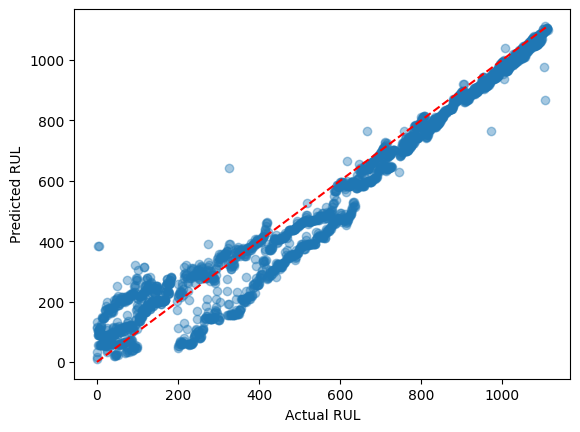

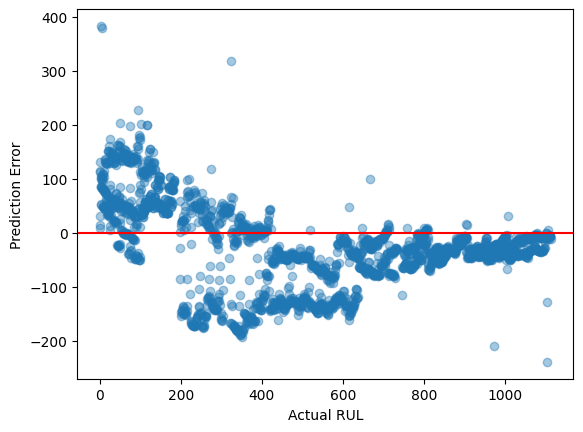

In [56]:
gb_model = GradientBoostingRegressor(
    n_estimators=250,           # Slightly increased from 200
    learning_rate=0.04,         # Slightly reduced from 0.05
    max_depth=4,                # Keep the same
    min_samples_split=4,        # Slightly reduced from 5
    min_samples_leaf=2,         # Added for stability
    subsample=0.85,             # Light stochastic sampling
    random_state=42
)

gb_model.fit(x_train,y_train)
y_pred_gb= gb_model.predict(x_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f"\nGradient Boosting RMSE: {rmse_gb:.2f}")
print(f"Gradient Boosting R²: {r2_gb:.4f}")

plt.scatter(y_test, gb_model.predict(x_test), alpha=0.4)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()

errors = gb_model.predict(x_test) - y_test

plt.scatter(y_test, errors, alpha=0.4)
plt.axhline(0, color="red")
plt.xlabel("Actual RUL")
plt.ylabel("Prediction Error")
plt.show()


In [57]:
features = test.drop(columns="RUL").columns

for i in range(10):
    sample_df = test.loc[[test.index[i]], features]  # keep as DataFrame
    sample_scaled = scaler.transform(sample_df)

    pred = gb_model.predict(sample_scaled)[0]
    actual = test.loc[test.index[i], "RUL"]
    error = abs(pred - actual)

    print(f"Sample {i}: Predicted={pred:.2f}, Actual={actual}, Error={error:.2f}")


Sample 0: Predicted=251.98, Actual=136, Error=115.98
Sample 1: Predicted=252.98, Actual=135, Error=117.98
Sample 2: Predicted=264.38, Actual=134, Error=130.38
Sample 3: Predicted=262.60, Actual=133, Error=129.60
Sample 4: Predicted=281.47, Actual=132, Error=149.47
Sample 5: Predicted=259.52, Actual=131, Error=128.52
Sample 6: Predicted=245.48, Actual=130, Error=115.48
Sample 7: Predicted=240.50, Actual=129, Error=111.50
Sample 8: Predicted=244.48, Actual=128, Error=116.48
Sample 9: Predicted=255.88, Actual=127, Error=128.88


Lightgdm

Starting Battery RUL Training...
Training until validation scores don't improve for 50 rounds
[100]	training's rmse: 58.5169	validation's rmse: 63.3382
[200]	training's rmse: 33.536	validation's rmse: 40.8276
[300]	training's rmse: 29.3797	validation's rmse: 37.6193
[400]	training's rmse: 27.0117	validation's rmse: 35.6243
[500]	training's rmse: 25.1083	validation's rmse: 34.0495
[600]	training's rmse: 23.4827	validation's rmse: 32.7582
[700]	training's rmse: 22.1701	validation's rmse: 31.8295
[800]	training's rmse: 21.0811	validation's rmse: 31.0948
[900]	training's rmse: 20.2046	validation's rmse: 30.5755
[1000]	training's rmse: 19.3869	validation's rmse: 30.0921
[1100]	training's rmse: 18.6249	validation's rmse: 29.5797
[1200]	training's rmse: 17.966	validation's rmse: 29.2118
[1300]	training's rmse: 17.4123	validation's rmse: 28.9282
[1400]	training's rmse: 16.8677	validation's rmse: 28.6177
[1500]	training's rmse: 16.3777	validation's rmse: 28.3569
[1600]	training's rmse: 15.9269	

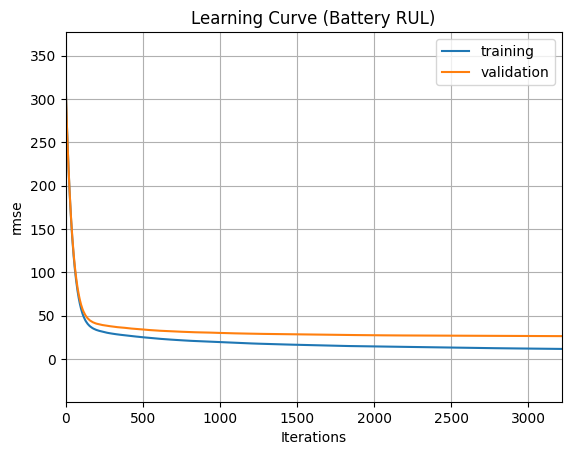


--- Final Evaluation ---
RMSE: 26.36
R²: 0.9933


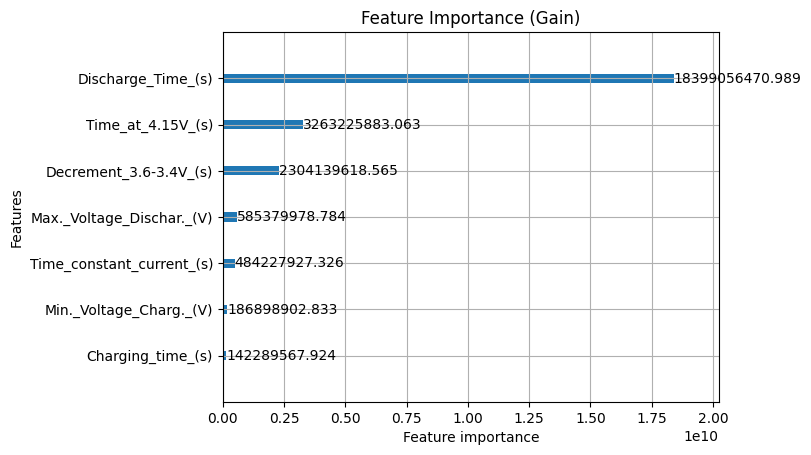

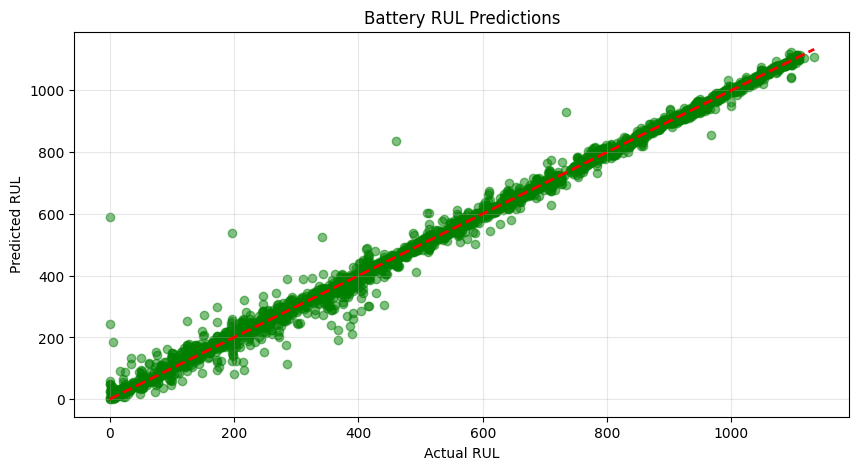

In [65]:
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# --- 1. Data Setup (Assuming you have loaded your dataframe as 'df') ---
# If you haven't split yet, here is a standard split
X = df.drop(columns=['RUL'])
y = df['RUL']

# Split into Train (80%) and Test (20%)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create LightGBM Datasets
# Note: We are NOT clipping the target here because Battery RUL is usually linear.
train_data = lgb.Dataset(x_train, label=y_train)
valid_data = lgb.Dataset(x_test, label=y_test, reference=train_data)

# --- 2. Hyperparameters for Battery Data ---
# Batteries are "smoother" than engines, so we can use a slightly higher learning rate
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,      # Slightly faster than the engine model
    'num_leaves': 31,           # Standard complexity
    'max_depth': -1,            # Let the tree grow deep (batteries have less noise)
    'feature_fraction': 0.9,    # Use 90% of features
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# --- 3. Training ---
evals_result = {}  # Store metrics history

print("Starting Battery RUL Training...")
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['training', 'validation'],
    num_boost_round=5000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # Stop if no improvement for 50 rounds
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(evals_result)     # Record history
    ]
)

# --- 4. Plot Learning Curve ---
try:
    lgb.plot_metric(evals_result, metric='rmse')
    plt.title("Learning Curve (Battery RUL)")
    plt.show()
except Exception as e:
    print(f"Plot error: {e}")

# --- 5. Final Evaluation ---
print("\n--- Final Evaluation ---")
y_pred = model.predict(x_test)
y_pred = np.maximum(y_pred, 0) # RUL cannot be negative

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

# --- 6. Feature Importance (Check which physics feature is best) ---
lgb.plot_importance(model, max_num_features=10, importance_type='gain')
plt.title("Feature Importance (Gain)")
plt.show()

# --- 7. Prediction vs Actual Plot ---
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Battery RUL Predictions")
plt.grid(True, alpha=0.3)
plt.show()

In [72]:
import pandas as pd


sample_data = {
    'Discharge Time (s)': [2595.30],
    'Decrement 3.6-3.4V (s)': [1151.488],
    'Max. Voltage Dischar. (V)': [3.670],
    'Min. Voltage Charg. (V)': [3.211],
    'Time at 4.15V (s)': [5460.001],
    'Time constant current (s)': [6755.01],
    'Charging time (s)': [10777.82]
}


input_df = pd.DataFrame(sample_data)


predicted_rul = model.predict(input_df)[0]
actual_rul = 1112 

print(f"--- Single Point Verification ---")
print(f"Input Features: {list(sample_data.values())}")
print(f"\nPredicted RUL: {predicted_rul:.2f}")
print(f"Actual RUL:    {actual_rul}")
print(f"Difference:    {predicted_rul - actual_rul:.2f}")

--- Single Point Verification ---
Input Features: [[2595.3], [1151.488], [3.67], [3.211], [5460.001], [6755.01], [10777.82]]

Predicted RUL: 1107.01
Actual RUL:    1112
Difference:    -4.99


saving best lightgdm model

In [73]:
import joblib


filename = 'battery_rul_model.pkl'


joblib.dump(model, filename)

print(f" Model saved successfully as '{filename}'")

 Model saved successfully as 'battery_rul_model.pkl'


LOad the model

In [74]:
import joblib
import pandas as pd

loaded_model = joblib.load('battery_rul_model.pkl')

print("Model loaded successfully")

input_values = [[1341.62, 369.50000, 3.870, 3.616, 2306.3120, 3104.31, 10777.82]]

prediction = loaded_model.predict(input_values)[0]
print(f"Predicted RUL from loaded model: {prediction:.2f}")

Model loaded successfully
Predicted RUL from loaded model: 340.16
